# Demo: `finTs` → `FinStrat` → `FinBT`

**Data.** Multi-ticker daily panel from `finTs` (OHLCV + engineered features). Strategy code only uses the OHLCV block via `ind.IX_LIVE`.

**Signal (inside the alpha passed to `FinStrat`).** For each name and date, define **close location value** (where the close sits in the day’s range):

\[
\text{close\_location\_value} = \frac{2\cdot \text{Close} - \text{High} - \text{Low}}{\text{High} - \text{Low}}
\]

(If the range is zero, we set the ratio to 0.) Then the raw cross-sectional score is \(-\,\text{close\_location\_value} \times \text{Volume}\); we turn that into a **rank** across names so the alpha is comparable across days:

\[
\alpha = \text{rank}\bigl(-\,\text{close\_location\_value}\times\text{Volume}\bigr).
\]

**Execution.** `FinStrat` applies your pipeline (here: market neutralization, optional BRAIN-style `decay` / `truncation`, etc.). `FinBT` backtests with backtrader on the same `finTs` instance.

**Why equity can stay flat for months.** By default, `panel_at` loads *every* live feature (including `SMA_200`, etc.). Until those are finite for enough names, the backtest never trades. This notebook passes `panel_columns=STRATEGY_PANEL_OHLCV_ONLY` so only OHLCV rows are required and trading can start on the first bar.

**`rank(-raw)` vs `rank(raw)`** — `rank` is monotone: smallest input → score `0`, largest → `1`. Negating the argument **reverses** who gets the high score (for distinct values, `rank(-raw) ≈ 1 - rank(raw)` per name). After market-demeaning, **dollar weights should flip sign** when you swap the two. If you see identical weights, re-run the strategy cell after editing, and compare `strat.scores(panel)` (not only gross notionals sorted by absolute value).

In [1]:
# OHLCV + features for a small universe (curl_cffi can reduce yfinance friction).

import urllib3
from curl_cffi import requests

from src.data.fints import finTs

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
session = requests.Session(impersonate="chrome", verify=False)

START, END = "2020-01-01", "2024-01-01"
TICKERS = ["AAPL", "MSFT", "GOOGL", "TSLA", "NVDA", "ORCL"]

data = finTs(
    start_date=START,
    end_date=END,
    ticker_list=TICKERS,
    session=session,
)
assert not data.df.empty, "yfinance returned no rows; check dates and symbols."
data.df.head()

Price                   Open       High        Low      Close     Volume  \
Ticker Date                                                                
AAPL   2020-01-02  71.409785  72.460784  71.156682  72.400520  135480400   
       2020-01-03  71.629130  72.455943  71.472447  71.696625  146322800   
       2020-01-06  70.819193  72.306491  70.568495  72.267921  118387200   
       2020-01-07  72.277578  72.533095  71.708695  71.928055  108872000   
       2020-01-08  71.631574  73.386446  71.631574  73.085129  132079200   

Price              SMA_50  SMA_200     RSI_14      MACD  MACD_Signal  ...  \
Ticker Date                                                           ...   
AAPL   2020-01-02     NaN      NaN        NaN  0.000000     0.000000  ...   
       2020-01-03     NaN      NaN   0.000000 -0.015793    -0.008774  ...   
       2020-01-06     NaN      NaN  46.639739 -0.002407    -0.006164  ...   
       2020-01-07     NaN      NaN  35.909736 -0.008531    -0.006966  ...   
       2020-01-08     NaN      NaN  65.234315  0.034364     0.005329  ...   

Price              ATR_14  Future_1d_Ret   Log_Ret  Dist_SMA50  Dist_SMA200  \
Ticker Date                                                                   
AAPL   2020-01-02     NaN      -0.009770       NaN         NaN          NaN   
       2020-01-03     NaN       0.007937 -0.009770         NaN          NaN   
       2020-01-06     NaN      -0.004714  0.007937         NaN          NaN   
       2020-01-07     NaN       0.015959 -0.004714         NaN          NaN   
       2020-01-08     NaN       0.021018  0.015959         NaN          NaN   

Price              BB_Width  BB_Position  MACD_Hist  ATR_Norm  Vol_Change  
Ticker Date                                                                
AAPL   2020-01-02       NaN          NaN   0.000000       NaN    0.000000  
       2020-01-03       NaN          NaN  -0.007019       NaN    0.080029  
       2020-01-06       NaN          NaN   0.003757       NaN   -0.190918  
       2020-01-07       NaN          NaN  -0.001565       NaN   -0.080374  
       2020-01-08       NaN          NaN   0.029035       NaN    0.213160  

[5 rows x 22 columns]

In [12]:
# Alpha: rank(-close_location_value * volume); bind FinStrat; preview one date.

import jax.numpy as jnp
import pandas as pd

from src.algorithm import FinStrat, cross_section as xs
from src.utils import indicators as ind

_RANGE_EPS = 1e-12


def alpha(panel: jnp.ndarray) -> jnp.ndarray:
    """Cross-sectional rank( - close_location_value * volume ); CLV computed here only."""
    high = panel[:, ind.IX_LIVE.HIGH]
    low = panel[:, ind.IX_LIVE.LOW]
    close = panel[:, ind.IX_LIVE.CLOSE]
    volume = panel[:, ind.IX_LIVE.VOLUME]

    day_range = high - low
    close_location_value = jnp.where(
        jnp.abs(day_range) > _RANGE_EPS,
        (2.0 * close - high - low) / day_range,
        0.0,
    )
    return xs.rank(-close_location_value*volume)


strat = FinStrat(
    data,
    alpha,
    decay=0.0,
    neutralization="market",
    truncation=0.0,
    jit_algorithm=True,
    panel_columns=ind.STRATEGY_PANEL_OHLCV_ONLY,
)

# Distinct cross-section → rank(-raw) + rank(raw) == 1 (elementwise)
_check = jnp.array([-3.0, 1.0, 0.0, 2.0, -1.0, 4.0], jnp.float32)
assert jnp.allclose(xs.rank(_check) + xs.rank(-_check), 1.0, rtol=1e-5, atol=1e-5)

# Last date with a clean multi-name panel (same ordering as finTs.ticker_list subset).
dates = data.df.index.get_level_values("Date").unique().sort_values()
as_of = None
panel, names = None, None
for dt in reversed(dates):
    try:
        panel, names = strat.panel_at(dt, live=True)
    except ValueError:
        continue
    if len(names) >= 2:
        as_of = dt
        break

if as_of is None:
    raise RuntimeError("No date had 2+ clean rows; widen the sample or check NaNs.")

print(f"as_of={as_of}  tickers={names}  panel_shape={panel.shape}")

scores = strat.scores(panel)
orders = strat.pass_(panel, capital=100_000.0, tickers=names)

pd.DataFrame(
    {"score": jnp.asarray(scores), "order_usd": jnp.asarray(orders)},
    index=names,
).sort_values("score", ascending=False)

as_of=2023-12-29 00:00:00  tickers=['AAPL', 'MSFT', 'GOOGL', 'TSLA', 'NVDA', 'ORCL']  panel_shape=(6, 5)


,score,order_usd
TSLA,1.0,27777.775391
AAPL,0.8,16666.667969
ORCL,0.6,5555.556641
GOOGL,0.4,-5555.554688
MSFT,0.2,-16666.667969
NVDA,0.0,-27777.775391


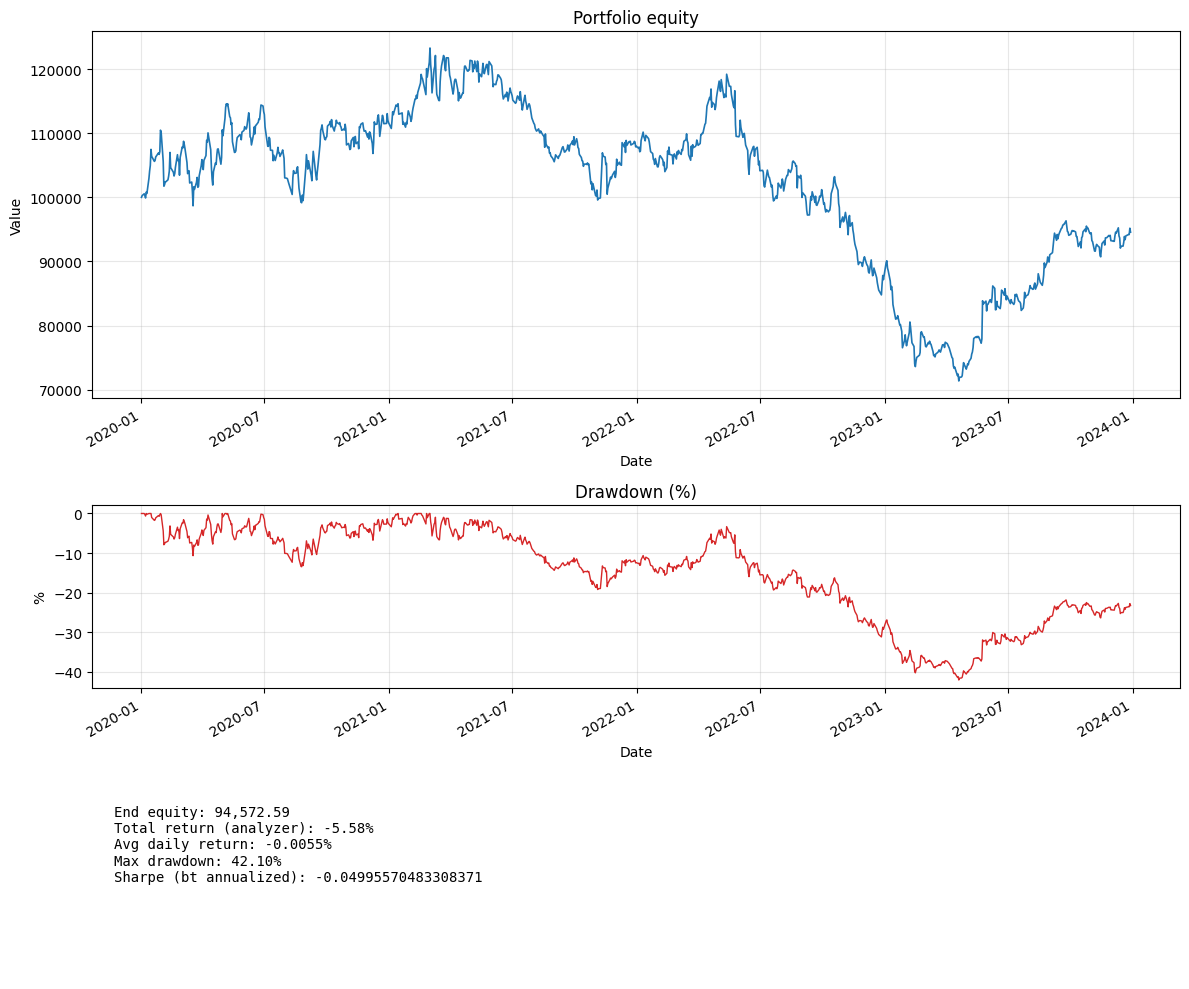

{'start_value': 100000.0,
 'end_value': 94572.58725794536,
 'total_return_pct': -5.580252720921934,
 'avg_daily_return_pct': -0.005546970895548642,
 'max_drawdown_pct': 42.102164076470125,
 'max_drawdown_len': 713,
 'sharpe_ratio': -0.04995570483308371}

In [13]:
# Same fin_ts as FinStrat; backtrader targets pass_ dollar notionals each bar.

from src.algorithm import FinBT

engine = FinBT(strat, data, cash=100_000.0, commission=0.0)
engine.run(stdstats=False)
summary = engine.results(show=True)
summary["metrics"]